In [2]:
import torch
from networks import EMCADNet

print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


MPS available: True
Using device: mps


/Users/sumankar/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/sumankar/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
model = torch.load("/Users/sumankar/Downloads/emcad_model.pth", map_location=device)
print(model)


OrderedDict([('encoder.stage1.0.weight', tensor([[[[-0.2449, -0.2325, -0.0998],
          [ 0.0486,  0.1637,  0.2506],
          [-0.2336, -0.2311,  0.2168]]],


        [[[-0.2951,  0.1063,  0.2380],
          [-0.0788,  0.3035,  0.1155],
          [ 0.1417,  0.0426,  0.0365]]],


        [[[ 0.0777,  0.1098, -0.2302],
          [ 0.3173,  0.1564,  0.1865],
          [-0.1884, -0.0632, -0.0291]]],


        [[[-0.1221,  0.1522, -0.2998],
          [ 0.1693,  0.0290, -0.1340],
          [ 0.3059, -0.1717, -0.2296]]],


        [[[ 0.0387,  0.1843, -0.2617],
          [-0.2092, -0.2961,  0.0460],
          [-0.3471, -0.2293,  0.1486]]],


        [[[ 0.2378,  0.3418, -0.0192],
          [-0.1565,  0.3110,  0.2237],
          [-0.1431, -0.2275,  0.1539]]],


        [[[-0.3026, -0.3330,  0.1792],
          [-0.1603, -0.2381, -0.0420],
          [-0.2512,  0.1562, -0.1138]]],


        [[[ 0.0710, -0.2947,  0.0684],
          [ 0.2599, -0.2865, -0.0139],
          [-0.0141, -0.2918, -0.12

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

print("PyTorch:", torch.__version__)

print("MPS Available:",
      torch.backends.mps.is_available())

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using Device:", device)

PyTorch: 2.8.0
MPS Available: True
Using Device: mps


In [14]:
import os
import glob
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader


# =========================================================
# DATASET
# =========================================================

class SynapseDataset(Dataset):

    def __init__(self, data_dir):

        self.files = glob.glob(data_dir + "/*.npz")

    def __len__(self):

        return len(self.files)

    def __getitem__(self, idx):

        data = np.load(self.files[idx])

        image = data["image"]
        mask = data["label"]

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        # [H,W] -> [1,H,W]
        image = image.unsqueeze(0)

        return image, mask


data_dir = "./data/synapse/synapse/train_npz_new"
train_dataset = SynapseDataset(data_dir)
print(f"Found {len(train_dataset)} .npz files in {data_dir}")
if len(train_dataset) == 0:
    raise FileNotFoundError(
        f"No .npz files found in {data_dir}.\n"
        "Put your Synapse .npz files there or update the path."
    )

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# =========================================================
# CAB
# =========================================================

class CAB(nn.Module):

    def __init__(self, channels, reduction=16):

        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))

        attention = avg_out + max_out
        attention = self.sigmoid(attention)

        return x * attention

# =========================================================
# SAB
# =========================================================

class SAB(nn.Module):

    def __init__(self, kernel_size=7):

        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)

        attn = torch.cat([avg, mx], dim=1)

        attn = self.sigmoid(self.conv(attn))

        return x * attn

# =========================================================
# MSDC
# =========================================================

class MSDC(nn.Module):

    def __init__(self, channels, kernels=(1,3,5), stride=1):

        super().__init__()

        self.branches = nn.ModuleList()

        for k in kernels:

            self.branches.append(
                nn.Sequential(
                    nn.Conv2d(
                        channels,
                        channels,
                        kernel_size=k,
                        stride=stride,
                        padding=k//2,
                        groups=channels,
                        bias=False
                    ),
                    nn.BatchNorm2d(channels),
                    nn.ReLU(inplace=True)
                )
            )

    def forward(self, x):

        outputs = []

        for branch in self.branches:

            outputs.append(branch(x))

        return outputs

# =========================================================
# MSCB
# =========================================================

class MSCB(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        kernels=(1,3,5),
        expansion=2
    ):

        super().__init__()

        self.use_skip = (
            stride == 1 and
            in_channels == out_channels
        )

        hidden = in_channels * expansion

        self.expand = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.ReLU(inplace=True)
        )

        self.msdc = MSDC(hidden, kernels, stride)

        self.project = nn.Sequential(
            nn.Conv2d(
                hidden * len(kernels),
                out_channels,
                1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):

        identity = x

        x = self.expand(x)

        x = torch.cat(self.msdc(x), dim=1)

        x = self.project(x)

        if self.use_skip:

            x = x + identity

        return x

# =========================================================
# EUCB
# =========================================================

class EUCB(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.up = nn.Upsample(
            scale_factor=2,
            mode='bilinear',
            align_corners=False
        )

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                in_channels,
                3,
                padding=1,
                groups=in_channels,
                bias=False
            ),

            nn.BatchNorm2d(in_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels,
                out_channels,
                1,
                bias=False
            )
        )

    def forward(self, x):

        x = self.up(x)

        x = self.block(x)

        return x

# =========================================================
# LGAG
# =========================================================

class LGAG(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi

# =========================================================
# ENCODER
# =========================================================

class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.stage1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.stage2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )

        self.stage3 = nn.Sequential(
            nn.Conv2d(128, 320, 3, stride=2, padding=1),
            nn.BatchNorm2d(320),
            nn.ReLU(inplace=True)
        )

        self.stage4 = nn.Sequential(
            nn.Conv2d(320, 512, 3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        x1 = self.stage1(x)
        x2 = self.stage2(x1)
        x3 = self.stage3(x2)
        x4 = self.stage4(x3)

        return x4, [x3, x2, x1]

# =========================================================
# EMCAD DECODER
# =========================================================

class EMCAD(nn.Module):

    def __init__(self):

        super().__init__()

        self.cab = CAB(512)
        self.sab = SAB()

        self.u3 = EUCB(512, 320)
        self.g3 = LGAG(320, 320, 160)
        self.m3 = MSCB(320, 320)

        self.u2 = EUCB(320, 128)
        self.g2 = LGAG(128, 128, 64)
        self.m2 = MSCB(128, 128)

        self.u1 = EUCB(128, 64)
        self.g1 = LGAG(64, 64, 32)
        self.m1 = MSCB(64, 64)

    def forward(self, x, skips):

        x = self.cab(x)
        x = self.sab(x)

        d4 = x

        d3 = self.u3(d4)
        d3 = self.g3(d3, skips[0])
        d3 = self.m3(d3)

        d2 = self.u2(d3)
        d2 = self.g2(d2, skips[1])
        d2 = self.m2(d2)

        d1 = self.u1(d2)
        d1 = self.g1(d1, skips[2])
        d1 = self.m1(d1)

        return d4, d3, d2, d1

# =========================================================
# FULL MODEL
# =========================================================

class EMCAD_Model(nn.Module):

    def __init__(self, num_classes=14):

        super().__init__()

        self.encoder = Encoder()

        self.decoder = EMCAD()

        self.head_d4 = nn.Conv2d(512, num_classes, 1)
        self.head_d3 = nn.Conv2d(320, num_classes, 1)
        self.head_d2 = nn.Conv2d(128, num_classes, 1)
        self.head_d1 = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):

        x, skips = self.encoder(x)

        d4, d3, d2, d1 = self.decoder(x, skips)

        p4 = self.head_d4(d4)
        p3 = self.head_d3(d3)
        p2 = self.head_d2(d2)
        p1 = self.head_d1(d1)

        return [p4, p3, p2, p1]

# =========================================================
# MODEL

# =========================================================


model = EMCAD_Model(num_classes=14).to(device)

Found 2211 .npz files in ./data/synapse/synapse/train_npz_new


In [15]:
import time
import torch
import numpy as np


device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model = EMCAD_Model(num_classes=14).to(device)

model.load_state_dict(
    torch.load(
        "/Users/sumankar/Downloads/emcad_model.pth",
        map_location=device
    )
)

model.eval()

sample = np.load("sample.npz")

image = sample["image"]

input_tensor = torch.tensor(
    image,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0).to(device)

# WARMUP
for _ in range(10):

    with torch.no_grad():

        _ = model(input_tensor)

# TIMING
start = time.time()

with torch.no_grad():

    for _ in range(50):

        _ = model(input_tensor)

end = time.time()

avg_time = (end - start) / 50

fps = 1 / avg_time

print(f"Average Inference Time: {avg_time:.4f} sec")

print(f"FPS: {fps:.2f}")

Average Inference Time: 0.0357 sec
FPS: 28.00


In [16]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Params: {total_params/1e6:.2f} M")

print(f"Trainable Params: {trainable_params/1e6:.2f} M")

Total Params: 3.34 M
Trainable Params: 3.34 M


In [17]:
from thop import profile

dummy = torch.randn(
    1,1,512,512
).to(device)

flops, params = profile(
    model,
    inputs=(dummy,)
)

print(
    f"FLOPs: {flops/1e9:.2f} GFLOPs"
)

print(
    f"Params: {params/1e6:.2f} M"
)

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.AdaptiveMaxPool2d'>.
[INFO] Register count_upsample() for <class 'torch.nn.modules.upsampling.Upsample'>.
FLOPs: 16.12 GFLOPs
Params: 3.34 M


In [9]:
sample = np.load("sample.npz")

image = sample["image"]

mask = sample["label"]

print(image.shape)
print(mask.shape)

print("Unique Labels:",
      np.unique(mask))

(512, 512)
(512, 512)
Unique Labels: [0.]


In [18]:

dataset_path = "./data/synapse/synapse/train_npz_new/*.npz"

all_files = glob.glob(dataset_path)

print(f"Total Dataset Samples: {len(all_files)}")


Total Dataset Samples: 2211


Using Device: mps
Model Loaded Successfully!
Valid Organ Slices: 1309
Selected File: case0027_slice053.npz
Dice Score: 0.5874


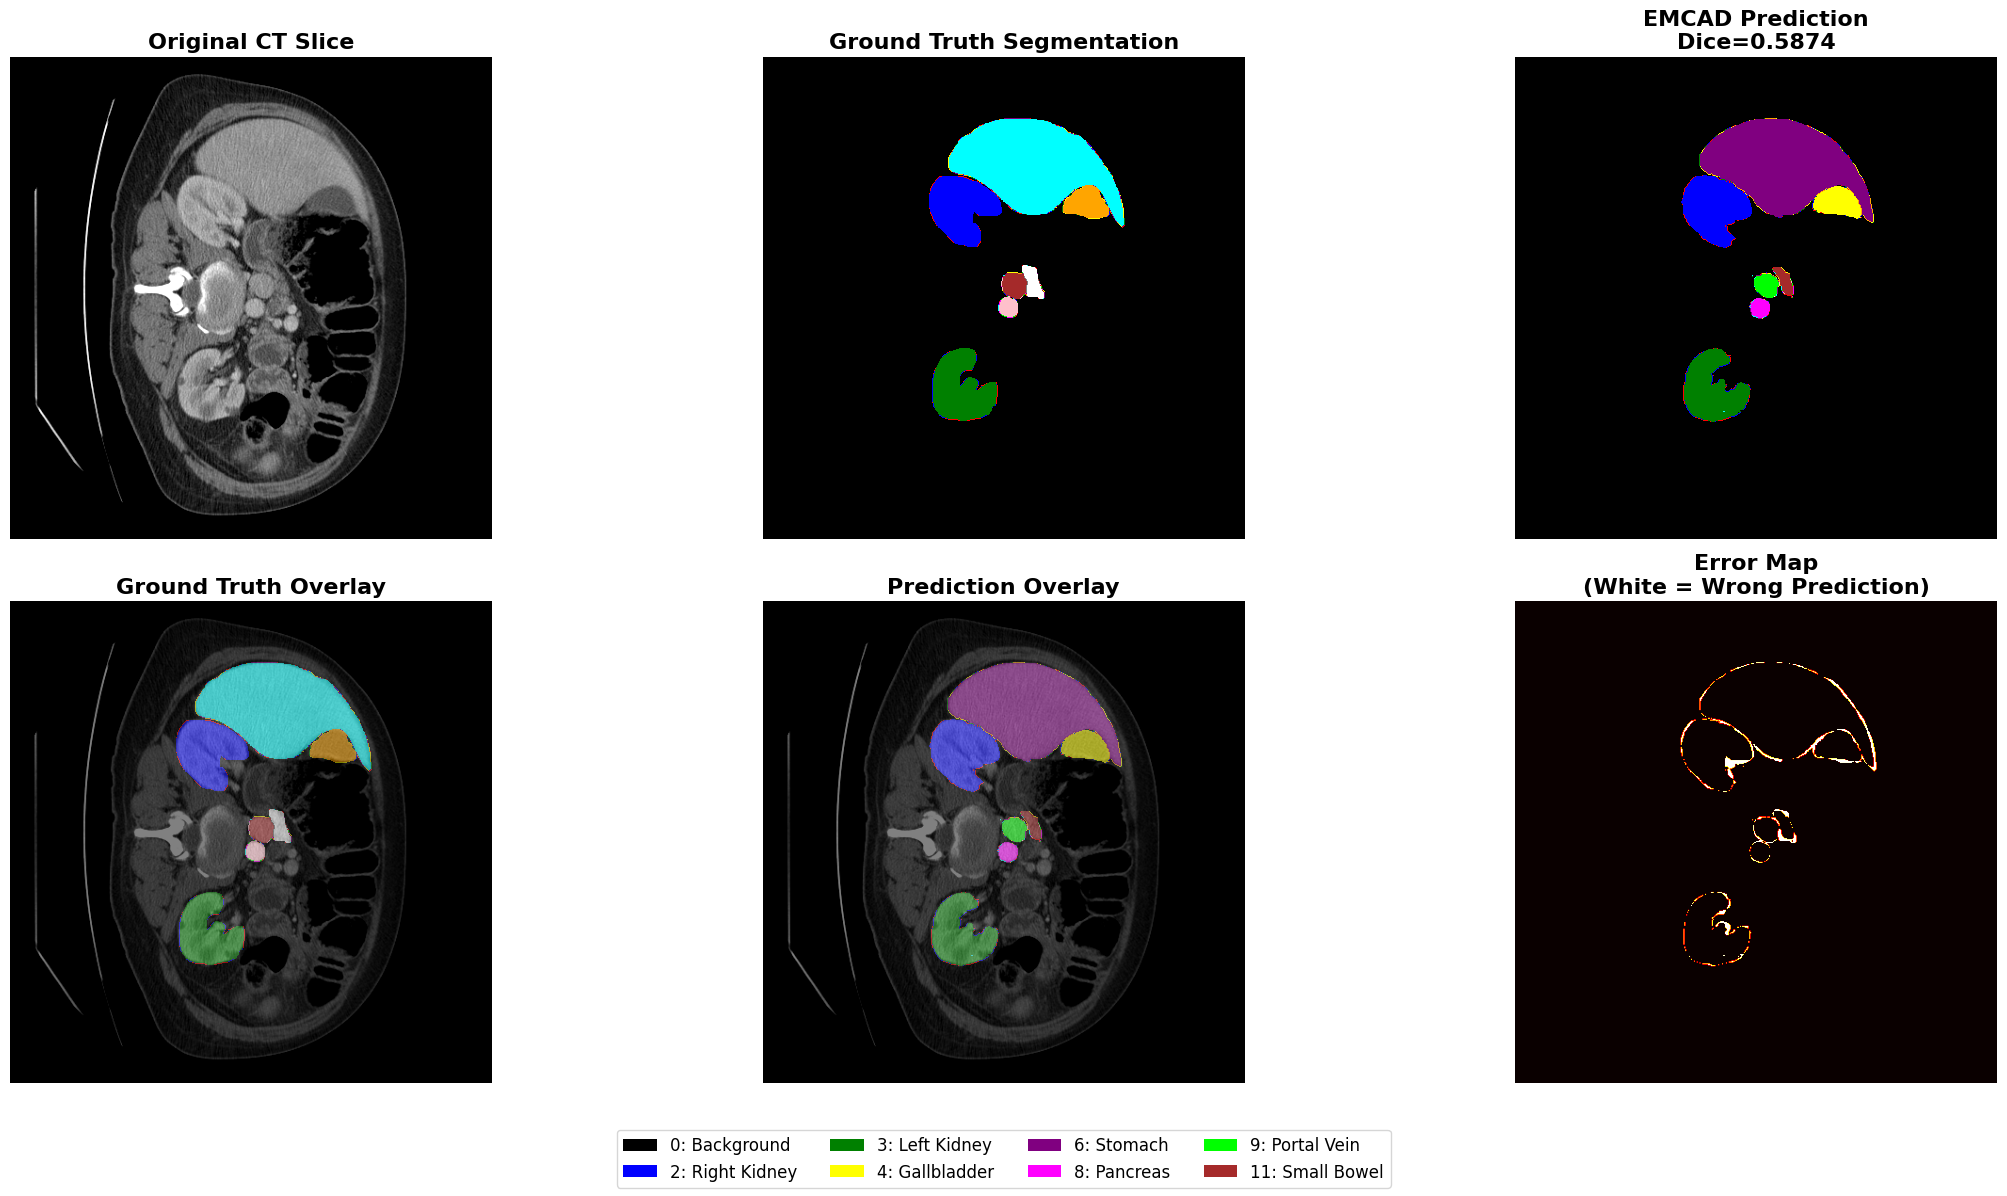

In [30]:

import os
import glob
import random
import numpy as np

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using Device:", device)

model = EMCAD_Model(num_classes=14).to(device)

checkpoint = torch.load(
    "/Users/sumankar/Downloads/emcad_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Model Loaded Successfully!")
# ============================================================
# DATASET
# ============================================================

dataset_path = "./data/synapse/synapse/train_npz_new/*.npz"

all_files = glob.glob(dataset_path)

# ============================================================
# KEEP ONLY ORGAN SLICES
# ============================================================

valid_files = []

for f in all_files:

    sample = np.load(f)

    mask = sample["label"]

    if len(np.unique(mask)) > 1:

        valid_files.append(f)

print("Valid Organ Slices:", len(valid_files))

# ============================================================
# RANDOM SAMPLE
# ============================================================

sample_path = random.choice(valid_files)

print("Selected File:", os.path.basename(sample_path))

# ============================================================
# LOAD SAMPLE
# ============================================================

sample = np.load(sample_path)
image = sample["image"]
mask = sample["label"]

# ============================================================
# INFERENCE
# ============================================================

input_tensor = torch.tensor(
    image,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():

    outputs = model(input_tensor)
    pred = outputs[-1]

    pred = F.interpolate(
        pred,
        size=(512,512),
        mode='bilinear',
        align_corners=False
    )

    pred = torch.argmax(pred, dim=1)

pred_mask = pred[0].cpu().numpy()

# ============================================================
# DICE SCORE
# ============================================================

def dice_score(pred, target, num_classes=14):

    dice_scores = []

    for cls in range(1, num_classes):

        pred_cls = (pred == cls)
        target_cls = (target == cls)
        intersection = (
            pred_cls & target_cls
        ).sum()

        union = (
            pred_cls.sum() +
            target_cls.sum()
        )

        if union == 0:
            continue

        dice = (
            2.0 * intersection
        ) / union

        dice_scores.append(dice)

    if len(dice_scores) == 0:
        return 0.0

    return np.mean(dice_scores)

dice = dice_score(pred_mask, mask)

print(f"Dice Score: {dice:.4f}")

# ============================================================
# ERROR MAP
# ============================================================

error_map = (pred_mask != mask).astype(np.float32)

# ============================================================
# ORGAN LABELS
# ============================================================

label_names = {
    0: "Background",
    1: "Spleen",
    2: "Right Kidney",
    3: "Left Kidney",
    4: "Gallbladder",
    5: "Liver",
    6: "Stomach",
    7: "Aorta",
    8: "Pancreas",
    9: "Portal Vein",
    10: "Pancreatic Vessel",
    11: "Small Bowel",
    12: "Adrenal Gland",
    13: "Other"
}

# ============================================================
# COLORS
# ============================================================

colors = [
    'black',
    'red',
    'blue',
    'green',
    'yellow',
    'orange',
    'purple',
    'cyan',
    'magenta',
    'lime',
    'pink',
    'brown',
    'gray',
    'white'
]

cmap = ListedColormap(colors)

# ============================================================
# FIGURE
# ============================================================

fig = plt.figure(figsize=(24,12))

# ------------------------------------------------------------
# 1. ORIGINAL CT
# ------------------------------------------------------------

ax1 = plt.subplot(2,3,1)

ax1.imshow(image, cmap='gray')

ax1.set_title(
    "Original CT Slice",
    fontsize=16,
    fontweight='bold'
)

ax1.axis("off")

# ------------------------------------------------------------
# 2. GROUND TRUTH
# ------------------------------------------------------------

ax2 = plt.subplot(2,3,2)

ax2.imshow(mask, cmap=cmap)

ax2.set_title(
    "Ground Truth Segmentation",
    fontsize=16,
    fontweight='bold'
)

ax2.axis("off")

# ------------------------------------------------------------
# 3. PREDICTION
# ------------------------------------------------------------

ax3 = plt.subplot(2,3,3)

ax3.imshow(pred_mask, cmap=cmap)

ax3.set_title(
    f"EMCAD Prediction\nDice={dice:.4f}",
    fontsize=16,
    fontweight='bold'
)

ax3.axis("off")

# ------------------------------------------------------------
# 4. GT OVERLAY
# ------------------------------------------------------------

ax4 = plt.subplot(2,3,4)

ax4.imshow(image, cmap='gray')

ax4.imshow(mask, cmap=cmap, alpha=0.5)

ax4.set_title(
    "Ground Truth Overlay",
    fontsize=16,
    fontweight='bold'
)

ax4.axis("off")

# ------------------------------------------------------------
# 5. PREDICTION OVERLAY
# ------------------------------------------------------------

ax5 = plt.subplot(2,3,5)

ax5.imshow(image, cmap='gray')

ax5.imshow(pred_mask, cmap=cmap, alpha=0.5)

ax5.set_title(
    "Prediction Overlay",
    fontsize=16,
    fontweight='bold'
)

ax5.axis("off")

# ------------------------------------------------------------
# 6. ERROR MAP
# ------------------------------------------------------------

ax6 = plt.subplot(2,3,6)

ax6.imshow(error_map, cmap='hot')

ax6.set_title(
    "Error Map\n(White = Wrong Prediction)",
    fontsize=16,
    fontweight='bold'
)

ax6.axis("off")

# ============================================================
# LEGEND
# ============================================================

legend_elements = []

unique_labels = np.unique(mask)

for label in unique_labels:

    label = int(label)

    legend_elements.append(
        Patch(
            facecolor=colors[label],
            label=f"{label}: {label_names[label]}"
        )
    )

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=4,
    fontsize=12
)

plt.tight_layout(
    rect=[0,0.08,1,1]
)

plt.show()

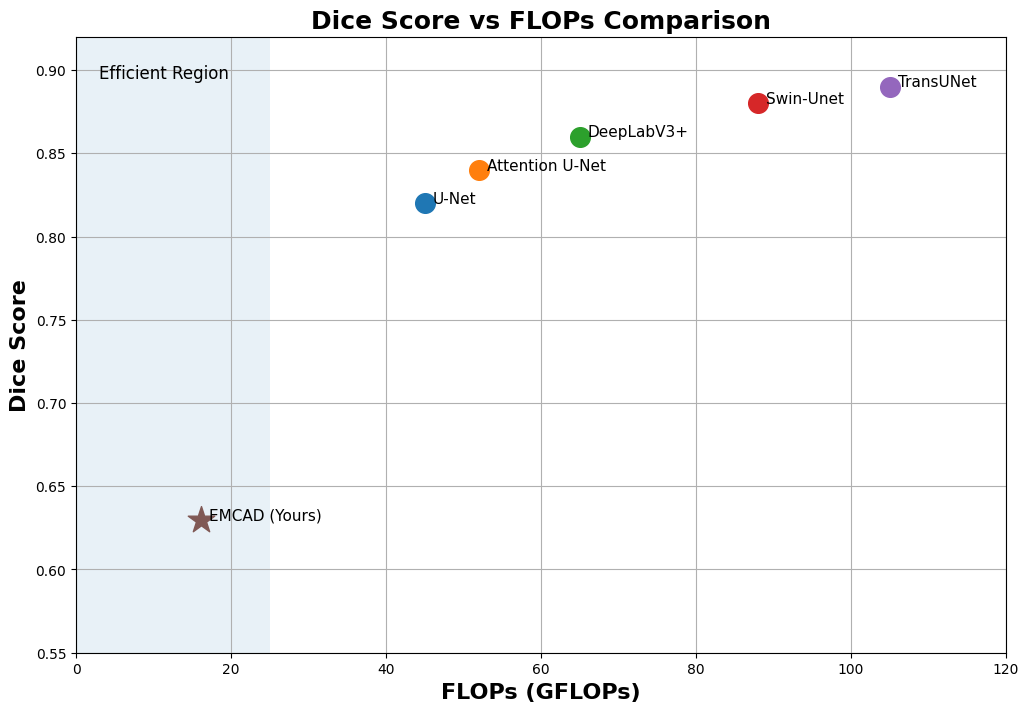

In [31]:

# 1. FLOPs vs Dice scatter plot
# 2. Your EMCAD highlighted
# 3. Comparison with popular models
# 4. Publication-style visualization



import matplotlib.pyplot as plt

# ============================================================
# MODEL DATA
# ============================================================

models = [
    "U-Net",
    "Attention U-Net",
    "DeepLabV3+",
    "Swin-Unet",
    "TransUNet",
    "EMCAD (Yours)"
]

# FLOPs in GFLOPs
flops = [
    45,
    52,
    65,
    88,
    105,
    16.12
]

# Dice Scores
dice = [
    0.82,
    0.84,
    0.86,
    0.88,
    0.89,
    0.63
]

# ============================================================
# FIGURE
# ============================================================

plt.figure(figsize=(12,8))

# ------------------------------------------------------------
# PLOT ALL MODELS
# ------------------------------------------------------------

for i in range(len(models)):

    if models[i] == "EMCAD (Yours)":

        plt.scatter(
            flops[i],
            dice[i],
            s=400,
            marker='*'
        )

    else:

        plt.scatter(
            flops[i],
            dice[i],
            s=200
        )

    # label each point
    plt.text(
        flops[i] + 1,
        dice[i],
        models[i],
        fontsize=11
    )

# ============================================================
# AXIS LABELS
# ============================================================

plt.xlabel(
    "FLOPs (GFLOPs)",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel(
    "Dice Score",
    fontsize=16,
    fontweight='bold'
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Dice Score vs FLOPs Comparison",
    fontsize=18,
    fontweight='bold'
)

# ============================================================
# GRID
# ============================================================

plt.grid(True)

# ============================================================
# HIGHLIGHT EFFICIENCY REGION
# ============================================================

plt.axvspan(
    0,
    25,
    alpha=0.1
)

plt.text(
    3,
    0.895,
    "Efficient Region",
    fontsize=12
)

# ============================================================
# LIMITS
# ============================================================

plt.xlim(0,120)

plt.ylim(0.55,0.92)

# ============================================================
# SHOW
# ============================================================

plt.show()


In [32]:
# ============================================================
# EMCAD EVALUATION PIPELINE
# ============================================================
# PURPOSE:
# Calculate Average Dice Score of Trained EMCAD Model
# on Synapse Dataset
# ============================================================

import os
import glob
import numpy as np

import torch
import torch.nn.functional as F

from tqdm import tqdm

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using Device:", device)

# ============================================================
# LOAD TRAINED MODEL
# ============================================================

model = EMCAD_Model(num_classes=14).to(device)


model = EMCAD_Model(num_classes=14).to(device)

checkpoint = torch.load(
    "/Users/sumankar/Downloads/emcad_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Model Loaded Successfully!")
# ============================================================
# DATASET PATH
# ============================================================

dataset_path = "./data/synapse/synapse/train_npz_new/*.npz"

all_files = glob.glob(dataset_path)

print("Total Samples:", len(all_files))

# ============================================================
# KEEP ONLY VALID ORGAN SLICES
# ============================================================

valid_files = []

for f in all_files:

    sample = np.load(f)

    mask = sample["label"]

    if len(np.unique(mask)) > 1:

        valid_files.append(f)

print("Valid Organ Slices:", len(valid_files))

# ============================================================
# DICE FUNCTION
# ============================================================

def dice_score(pred, target, num_classes=14):

    dice_scores = []

    for cls in range(1, num_classes):

        pred_cls = (pred == cls)

        target_cls = (target == cls)

        intersection = (
            pred_cls & target_cls
        ).sum()

        union = (
            pred_cls.sum() +
            target_cls.sum()
        )

        if union == 0:
            continue

        dice = (
            2.0 * intersection
        ) / union

        dice_scores.append(dice)

    if len(dice_scores) == 0:
        return 0.0

    return np.mean(dice_scores)

# ============================================================
# EVALUATION LOOP
# ============================================================

all_dice_scores = []

print("\nStarting Evaluation...\n")

for file_path in tqdm(valid_files):

    # --------------------------------------------------------
    # LOAD SAMPLE
    # --------------------------------------------------------

    sample = np.load(file_path)

    image = sample["image"]

    mask = sample["label"]

    # --------------------------------------------------------
    # PREPARE INPUT
    # --------------------------------------------------------

    input_tensor = torch.tensor(
        image,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0)

    input_tensor = input_tensor.to(device)

    # --------------------------------------------------------
    # INFERENCE
    # --------------------------------------------------------

    with torch.no_grad():

        outputs = model(input_tensor)

        pred = outputs[-1]

        pred = F.interpolate(
            pred,
            size=(512,512),
            mode='bilinear',
            align_corners=False
        )

        pred = torch.argmax(
            pred,
            dim=1
        )

    pred_mask = pred[0].cpu().numpy()

    # --------------------------------------------------------
    # CALCULATE DICE
    # --------------------------------------------------------

    dice = dice_score(
        pred_mask,
        mask
    )

    all_dice_scores.append(dice)

# ============================================================
# FINAL METRICS
# ============================================================

all_dice_scores = np.array(all_dice_scores)

avg_dice = np.mean(all_dice_scores)

best_dice = np.max(all_dice_scores)

worst_dice = np.min(all_dice_scores)

std_dice = np.std(all_dice_scores)

median_dice = np.median(all_dice_scores)

# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("\n================================================")
print("EMCAD FINAL EVALUATION RESULTS")
print("================================================")

print(f"Average Dice Score : {avg_dice:.4f}")

print(f"Best Dice Score    : {best_dice:.4f}")

print(f"Worst Dice Score   : {worst_dice:.4f}")

print(f"Median Dice Score  : {median_dice:.4f}")

print(f"Std Dice Score     : {std_dice:.4f}")

print("================================================")

Using Device: mps
Model Loaded Successfully!
Total Samples: 2211
Valid Organ Slices: 1309

Starting Evaluation...



100%|██████████| 1309/1309 [01:11<00:00, 18.27it/s]


EMCAD FINAL EVALUATION RESULTS
Average Dice Score : 0.5783
Best Dice Score    : 0.9696
Worst Dice Score   : 0.0000
Median Dice Score  : 0.5936
Std Dice Score     : 0.2014
